In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
import lightgbm as lgb
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\marketing_AB.csv")

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [6]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

In [7]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [9]:
df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [10]:
df.head(2)

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22


In [11]:
# Distribution of test_group
print(df['test group'].value_counts(normalize=True))

# Conversion rate overall
print(f"Overall CR: {df['converted'].mean():.4f}")

# total ads distribution
df['total ads'].describe(percentiles=[.25,.5,.75,.9,.95,.99])

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64
Overall CR: 0.0252


count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
90%          57.000000
95%          88.000000
99%         202.000000
max        2065.000000
Name: total ads, dtype: float64

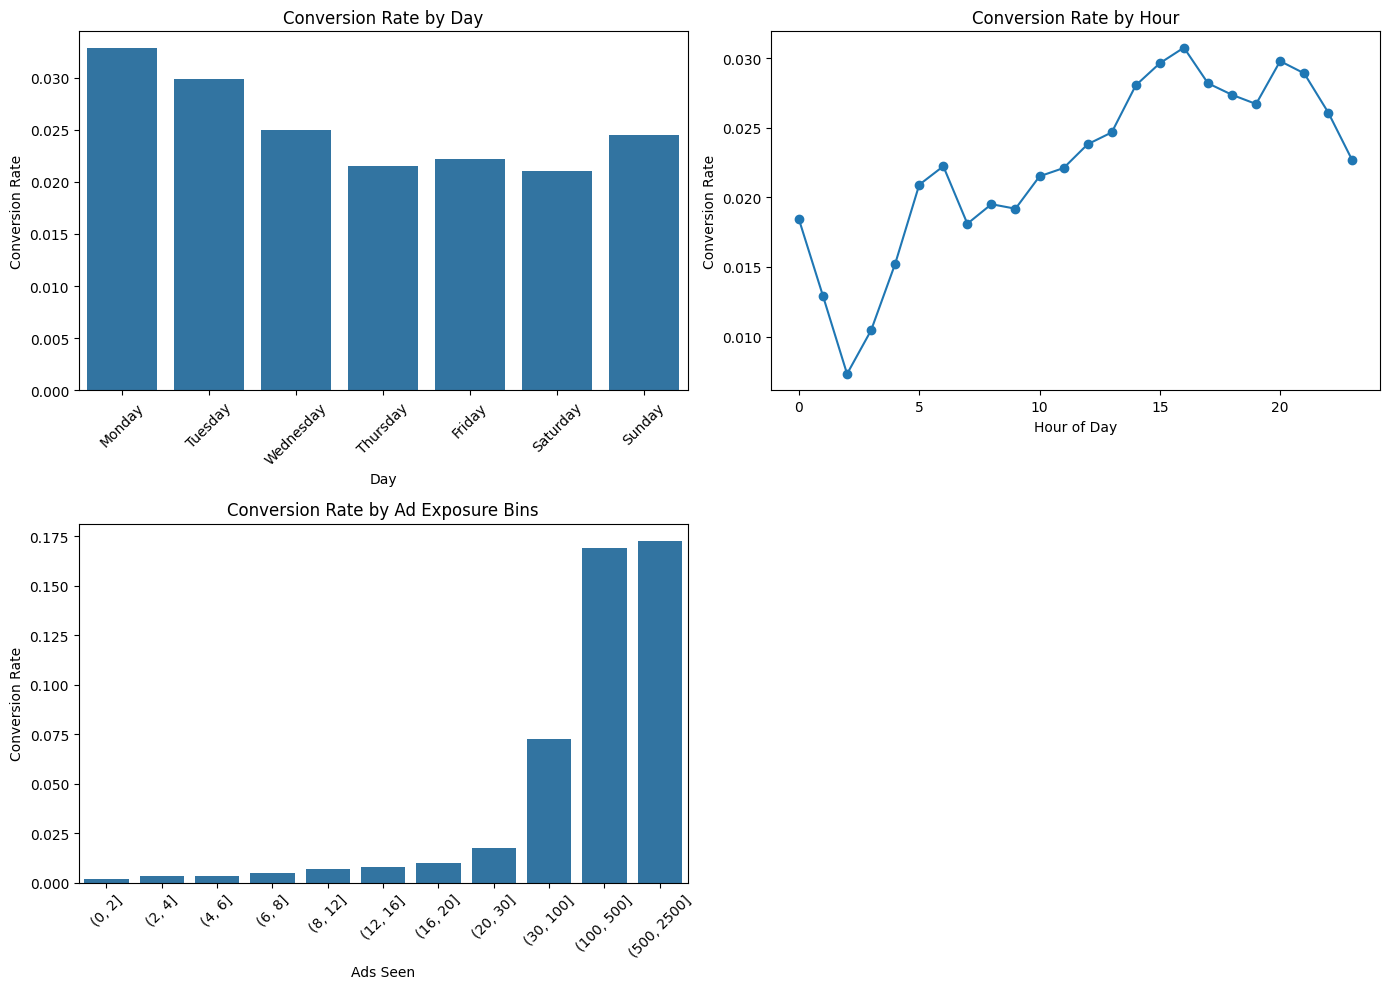

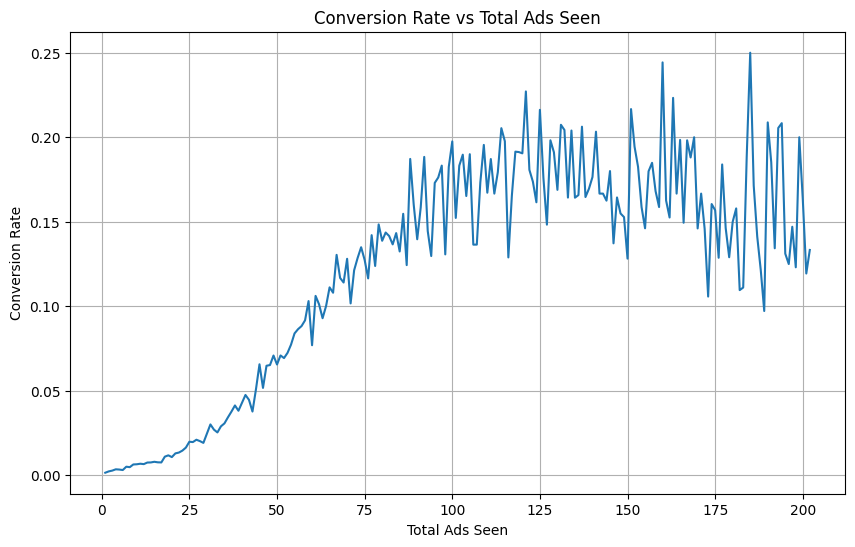

In [12]:


df = df.rename(columns={'most ads day':'most_ads_day', 'most ads hour':'most_ads_hour', 'total ads':'total_ads', 'test group':'test_group'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Conversion Rate by Day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_cr = df.groupby('most_ads_day')['converted'].mean().reindex(day_order).reset_index()

sns.barplot(data=day_cr, x='most_ads_day', y='converted', ax=axes[0,0])
axes[0,0].set_title('Conversion Rate by Day')
axes[0,0].set_xlabel('Day')
axes[0,0].set_ylabel('Conversion Rate')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Conversion Rate by Hour
hourly_cr = df.groupby('most_ads_hour')['converted'].mean().reset_index()

axes[0,1].plot(hourly_cr['most_ads_hour'], hourly_cr['converted'], marker='o')
axes[0,1].set_title('Conversion Rate by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Conversion Rate')

# 3. Conversion Rate by Ad Exposure Bins
df['ads_bin'] = pd.cut(df['total_ads'], bins=[0,2,4,6,8,12,16,20,30,100,500,2500])

ads_cr = df.groupby('ads_bin', observed=True)['converted'].mean().reset_index()

sns.barplot(data=ads_cr, x='ads_bin', y='converted', ax=axes[1,0])
axes[1,0].set_title('Conversion Rate by Ad Exposure Bins')
axes[1,0].set_xlabel('Ads Seen')
axes[1,0].set_ylabel('Conversion Rate')
axes[1,0].tick_params(axis='x', rotation=45)

fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

# 4. Conversion Rate vs Total Ads Seen
max_ads = df['total_ads'].quantile(0.99)
curve = df[df['total_ads'] <= max_ads].groupby('total_ads')['converted'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=curve, x='total_ads', y='converted')
plt.title('Conversion Rate vs Total Ads Seen')
plt.xlabel('Total Ads Seen')
plt.ylabel('Conversion Rate')
plt.grid(True)
plt.show()

In [13]:
# Calculate conversions
n_ad = df[df['test_group']=='ad'].shape[0]
n_psa = df[df['test_group']=='psa'].shape[0]
conv_ad = df[df['test_group']=='ad']['converted'].sum()
conv_psa = df[df['test_group']=='psa']['converted'].sum()

cr_ad = conv_ad / n_ad
cr_psa = conv_psa / n_psa
abs_lift = cr_ad - cr_psa
rel_lift = abs_lift / cr_psa * 100

print(f"Ad CR: {cr_ad:.4f} ({conv_ad}/{n_ad})")
print(f"PSA CR: {cr_psa:.4f} ({conv_psa}/{n_psa})")
print(f"Absolute lift: {abs_lift:.4f} ({abs_lift*100:.2f} pp)")
print(f"Relative lift: {rel_lift:.1f}%")

# Two-proportion z-test (one-sided)
count = np.array([conv_ad, conv_psa])
nobs = np.array([n_ad, n_psa])
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f"Z-statistic: {z_stat:.4f}, p-value: {p_value:.10f}")

# Confidence interval for difference (95%)
p_diff = cr_ad - cr_psa
se_diff = np.sqrt(cr_ad*(1-cr_ad)/n_ad + cr_psa*(1-cr_psa)/n_psa)
ci_low = p_diff - 1.96*se_diff
ci_high = p_diff + 1.96*se_diff
print(f"95% CI for difference: [{ci_low:.4f}, {ci_high:.4f}]")

# Chi-square test (for independence between group and conversion)
contingency = pd.crosstab(df['test_group'], df['converted'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)
print(f"Chi-square p-value: {p_chi:.10f}")

# Effect size (Cohen's h)
from statsmodels.stats.proportion import proportion_effectsize
h = proportion_effectsize(cr_ad, cr_psa)
print(f"Cohen's h: {h:.3f} (small=0.2, medium=0.5, large=0.8)")

Ad CR: 0.0255 (14423/564577)
PSA CR: 0.0179 (420/23524)
Absolute lift: 0.0077 (0.77 pp)
Relative lift: 43.1%
Z-statistic: 7.3701, p-value: 0.0000000000
95% CI for difference: [0.0060, 0.0094]
Chi-square p-value: 0.0000000000
Cohen's h: 0.053 (small=0.2, medium=0.5, large=0.8)
